<a href="https://colab.research.google.com/github/shanza1608/AI-Plant-Disease-Detection/blob/main/mobileusageLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [131]:
df=pd.read_csv("/content/sample_data/mobile_productivity.csv")
df

,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,6.5,3.2,7.0,72.5
1,8.0,5.1,5.5,55.0
2,NaN,NaN,NaN,NaN
3,4.2,2.0,8.5,85.0
4,-2.5,4.8,6.0,60.3
5,7.8,NaN,4.5,48.2
6,3.0,1.5,9.0,90.1


In [132]:
df = df.abs()

In [133]:
df['App_Usage_hrs']=df['App_Usage_hrs'].fillna(df['App_Usage_hrs'].mean())
df['Screen_Time_hrs']=df['Screen_Time_hrs'].fillna(df['Screen_Time_hrs'].mean())
df['Sleep_hrs']=df['Sleep_hrs'].fillna(df['Sleep_hrs'].mean())
df['Productivity_score']=df['Productivity_score'].fillna(df['Productivity_score'].mean())
df = df.round(2)
df

,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,6.50,3.20,7.00,72.50
1,8.00,5.10,5.50,55.00
2,5.33,3.32,6.75,68.52
3,4.20,2.00,8.50,85.00
4,2.50,4.80,6.00,60.30
5,7.80,3.32,4.50,48.20
6,3.00,1.50,9.00,90.10


In [134]:
df.to_csv("/content/sample_data/cleanMU.csv")
df

,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,6.50,3.20,7.00,72.50
1,8.00,5.10,5.50,55.00
2,5.33,3.32,6.75,68.52
3,4.20,2.00,8.50,85.00
4,2.50,4.80,6.00,60.30
5,7.80,3.32,4.50,48.20
6,3.00,1.50,9.00,90.10


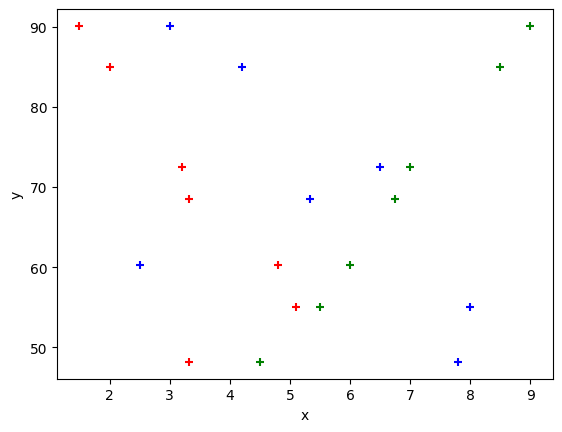

In [135]:
x=df[['App_Usage_hrs','Screen_Time_hrs','Sleep_hrs']]
y=df['Productivity_score']
%matplotlib inline
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(df['App_Usage_hrs'], df['Productivity_score'], color='red', marker='+')
plt.scatter(df['Screen_Time_hrs'], df['Productivity_score'], color='blue', marker='+')
plt.scatter(df['Sleep_hrs'], df['Productivity_score'], color='green', marker='+')
plt.show()

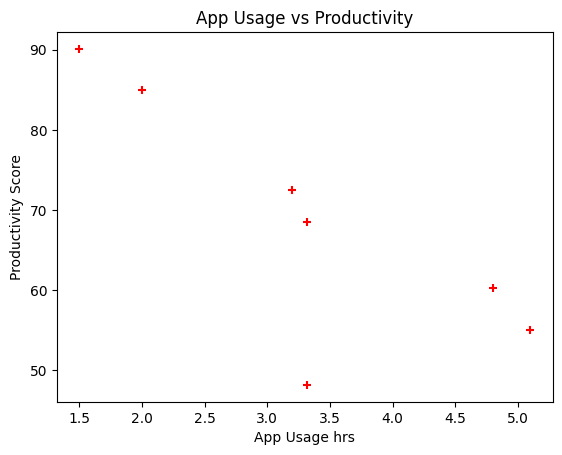

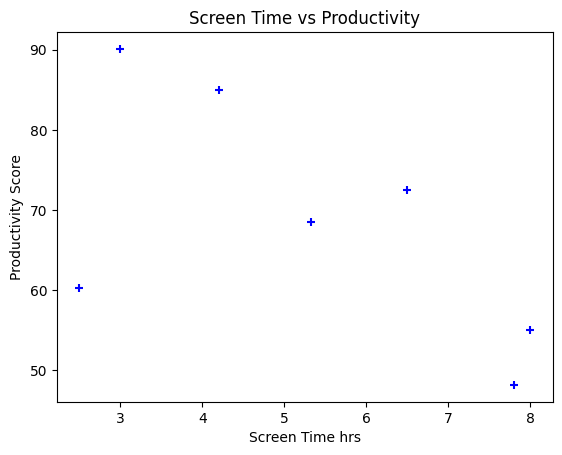

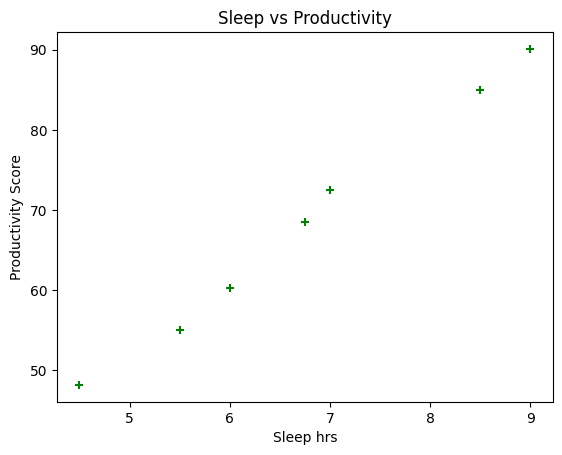

In [136]:
import matplotlib.pyplot as plt
X = df[['App_Usage_hrs', 'Screen_Time_hrs', 'Sleep_hrs']]
y = df['Productivity_score']
%matplotlib inline
# App Usage vs Productivity
plt.scatter(df['App_Usage_hrs'], df['Productivity_score'], color='red', marker='+')
plt.xlabel('App Usage hrs')
plt.ylabel('Productivity Score')
plt.title('App Usage vs Productivity')
plt.show()
# Screen Time vs Productivity
plt.scatter(df['Screen_Time_hrs'], df['Productivity_score'], color='blue', marker='+')
plt.xlabel('Screen Time hrs')
plt.ylabel('Productivity Score')
plt.title('Screen Time vs Productivity')
plt.show()
# Sleep vs Productivity
plt.scatter(df['Sleep_hrs'], df['Productivity_score'], color='green', marker='+')
plt.xlabel('Sleep hrs')
plt.ylabel('Productivity Score')
plt.title('Sleep vs Productivity')
plt.show()

In [137]:
reg=linear_model.LinearRegression()
reg.fit(df[['App_Usage_hrs','Screen_Time_hrs','Sleep_hrs']],df.Productivity_score)

LinearRegression()

In [138]:
reg.predict([[15,16,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42.5210041])

In [139]:
reg.coef_

array([-0.94788252,  0.08483711,  9.04562317])

In [140]:
reg.intercept_

np.float64(10.153732216842982)

In [141]:
reg.predict([[8,6,10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([93.53592645])

In [142]:
d=pd.read_csv("/content/sample_data/mobile_predict_empty.csv")
d

,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,2.5,1.2,8.0,NaN
1,9.0,6.5,4.5,NaN
2,5.0,3.0,7.5,NaN
3,7.5,5.0,5.0,NaN
4,3.5,2.0,8.5,NaN
5,8.5,6.0,4.0,NaN
6,4.0,2.5,7.0,NaN
7,6.5,4.2,6.0,NaN
8,1.5,0.8,9.0,NaN
9,10.0,7.5,3.5,NaN


In [143]:
print(d.isnull().sum())

Screen_Time_hrs        0
App_Usage_hrs          0
Sleep_hrs              0
Productivity_score    10
dtype: int64


In [144]:
d["Productivity_score"].fillna(0,inplace=True)
d

/tmp/ipykernel_12342/1707487082.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["Productivity_score"].fillna(0,inplace=True)


,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,2.5,1.2,8.0,0.0
1,9.0,6.5,4.5,0.0
2,5.0,3.0,7.5,0.0
3,7.5,5.0,5.0,0.0
4,3.5,2.0,8.5,0.0
5,8.5,6.0,4.0,0.0
6,4.0,2.5,7.0,0.0
7,6.5,4.2,6.0,0.0
8,1.5,0.8,9.0,0.0
9,10.0,7.5,3.5,0.0


In [145]:
#d.to_csv("/content/sample_data/newPredicted.csv")

In [146]:
reg=linear_model.LinearRegression()
reg.fit(df[['App_Usage_hrs','Screen_Time_hrs','Sleep_hrs']],df.Productivity_score)



LinearRegression()

In [147]:
newdata=reg.predict(d[['App_Usage_hrs','Screen_Time_hrs','Sleep_hrs']])
newdata
d['Productivity_score']=newdata
d.to_csv("/content/sample_data/newPredicted.csv")
d

,Screen_Time_hrs,App_Usage_hrs,Sleep_hrs,Productivity_score
0,2.5,1.2,8.0,81.593351
1,9.0,6.5,4.5,45.461334
2,5.0,3.0,7.5,75.576444
3,7.5,5.0,5.0,51.278714
4,3.5,2.0,8.5,85.442694
5,8.5,6.0,4.0,41.370045
6,4.0,2.5,7.0,71.442737
7,6.5,4.2,6.0,60.997806
8,1.5,0.8,9.0,90.933290
9,10.0,7.5,3.5,35.552666


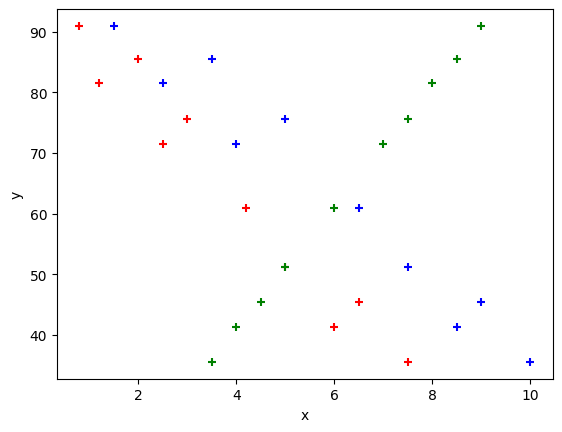

In [148]:
x=d[['App_Usage_hrs','Screen_Time_hrs','Sleep_hrs']]
y=d['Productivity_score']
%matplotlib inline
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(d['App_Usage_hrs'], d['Productivity_score'], color='red', marker='+')
plt.scatter(d['Screen_Time_hrs'], d['Productivity_score'], color='blue', marker='+')
plt.scatter(d['Sleep_hrs'], d['Productivity_score'], color='green', marker='+')
plt.show()